In [6]:
import pandas as pd
df=pd.read_csv("data/egx/ABUK.csv")
df.head()

,date,open,high,low,close,volume
0,2015-01-04,10.666666,10.666666,10.666666,10.666666,0
1,2015-01-05,10.666666,10.800000,10.373333,10.794666,295290
2,2015-01-06,10.794666,10.800000,10.800000,10.800000,765000
3,2015-01-08,10.800000,10.400666,10.400666,10.800000,255
4,2015-01-11,10.800000,10.800000,10.800000,10.800000,0


In [7]:
df["MA9"] = df["close"].rolling(window=9).mean()

df["MA20"] = df["close"].rolling(window=20).mean()

df.head(25)

,date,open,high,low,close,volume,MA9,MA20
0,2015-01-04,10.666666,10.666666,10.666666,10.666666,0,NaN,NaN
1,2015-01-05,10.666666,10.800000,10.373333,10.794666,295290,NaN,NaN
2,2015-01-06,10.794666,10.800000,10.800000,10.800000,765000,NaN,NaN
3,2015-01-08,10.800000,10.400666,10.400666,10.800000,255,NaN,NaN
4,2015-01-11,10.800000,10.800000,10.800000,10.800000,0,NaN,NaN
5,2015-01-12,10.800000,10.800000,10.800000,10.800000,0,NaN,NaN
6,2015-01-13,10.800000,10.800000,10.800000,10.800000,0,NaN,NaN
7,2015-01-14,10.800000,10.800000,10.800000,10.800000,0,NaN,NaN
8,2015-01-15,10.800000,10.800000,10.536666,10.796666,126075,10.784222,NaN
9,2015-01-18,10.796666,10.666666,10.540000,10.565333,5385,10.772963,NaN


In [8]:
df.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'MA9', 'MA20'], dtype='str')

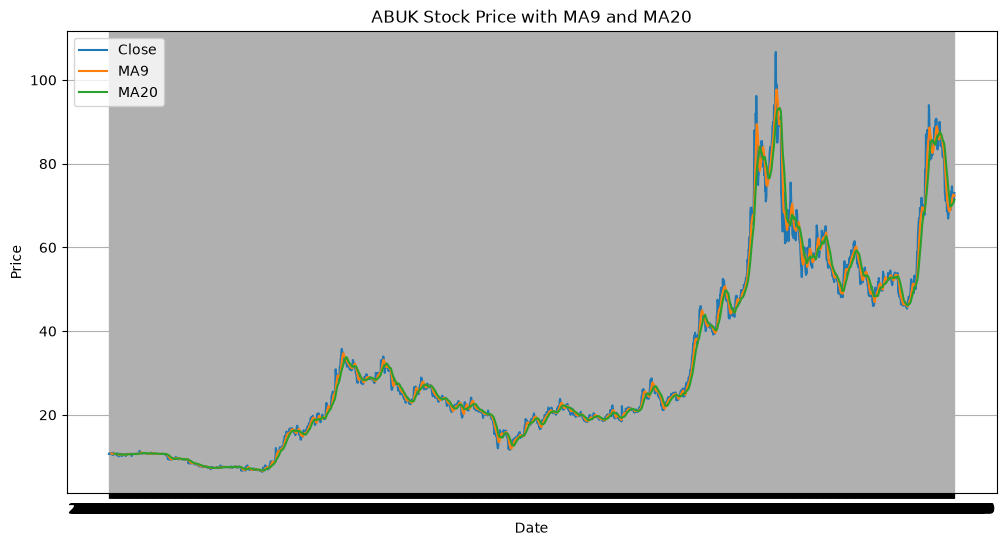

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df["date"], df["close"], label="Close")
plt.plot(df["date"], df["MA9"], label="MA9")
plt.plot(df["date"], df["MA20"], label="MA20")

plt.title("ABUK Stock Price with MA9 and MA20")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()

In [14]:
cash = 1000.0
shares = 0
position = False

buy_dates = []
buy_prices = []

sell_dates = []
sell_prices = []

portfolio_values = []

In [15]:
for i in range(20, len(df)):

    price = df["close"].iloc[i]
    ma9 = df["MA9"].iloc[i]
    ma20 = df["MA20"].iloc[i]

    # Buy
    if ma9 > ma20 and not position:

        shares = cash / price
        cash = 0
        position = True

        buy_dates.append(df["date"].iloc[i])
        buy_prices.append(price)

    # Sell
    elif ma9 < ma20 and position:

        cash = shares * price
        shares = 0
        position = False

        sell_dates.append(df["date"].iloc[i])
        sell_prices.append(price)

    # Portfolio Value
    if position:
        portfolio = shares * price
    else:
        portfolio = cash

    portfolio_values.append(portfolio)

In [16]:
last_price = df["close"].iloc[-1]

if position:
    final_portfolio_value = shares * last_price
else:
    final_portfolio_value = cash

print(f"Final Portfolio Value: {final_portfolio_value:.2f} EGP")

Final Portfolio Value: 4235.43 EGP


In [17]:
portfolio_values

[1000.0,
 1000.0,
 1000.0,
 1000.0,
 1000.0,
 1000.0,
 1000.0,
 1000.0,
 1000.0,
 1000.0,
 1000.0,
 1000.0,
 1000.0,
 1000.0,
 1000.0,
 1000.0,
 1000.0,
 1000.0,
 1000.0,
 1000.0,
 1000.0,
 1000.0,
 np.float64(1000.0000000000001),
 np.float64(1000.0000000000001),
 np.float64(1005.7765093003903),
 np.float64(1005.7765093003903),
 np.float64(1048.24731828401),
 np.float64(1048.24731828401),
 np.float64(1048.24731828401),
 np.float64(1048.24731828401),
 np.float64(1048.24731828401),
 np.float64(1048.24731828401),
 np.float64(1048.24731828401),
 np.float64(1048.24731828401),
 np.float64(1022.6338028556938),
 np.float64(1021.0535507748612),
 np.float64(1020.5925771989182),
 np.float64(1003.670401119394),
 np.float64(1003.670401119394),
 np.float64(1003.670401119394),
 np.float64(1003.6704011193941),
 np.float64(1003.6704011193941),
 np.float64(1003.6704011193941),
 np.float64(1003.6704011193941),
 np.float64(1003.6704011193941),
 np.float64(1003.6704011193941),
 np.float64(1004.611363712959

In [18]:
import pandas as pd

portfolio_df = pd.DataFrame({
    "Portfolio": portfolio_values
})

portfolio_df.head()

,Portfolio
0,1000.0
1,1000.0
2,1000.0
3,1000.0
4,1000.0


In [19]:
portfolio_df["Peak"] = portfolio_df["Portfolio"].cummax()

In [20]:
portfolio_df.head()

,Portfolio,Peak
0,1000.0,1000.0
1,1000.0,1000.0
2,1000.0,1000.0
3,1000.0,1000.0
4,1000.0,1000.0


In [22]:
portfolio_df["Drawdown"] = (
    portfolio_df["Portfolio"] - portfolio_df["Peak"]
) / portfolio_df["Peak"]

In [23]:
max_drawdown = portfolio_df["Drawdown"].min()

print(f"Maximum Drawdown: {max_drawdown:.2%}")

Maximum Drawdown: -48.23%


In [24]:
buy_count = len(buy_dates)
sell_count = len(sell_dates)

print(f"Number of Buy Operations : {buy_count}")
print(f"Number of Sell Operations: {sell_count}")

Number of Buy Operations : 83
Number of Sell Operations: 82


In [26]:
print(len(buy_dates))
print(len(buy_prices))

print(len(sell_dates))
print(len(sell_prices))

83
83
82
82


In [27]:
print(buy_dates[:5])
print(buy_prices[:5])

['2015-03-05', '2015-03-18', '2015-03-31', '2015-04-05', '2015-05-10']
[np.float64(10.156000137329102), np.float64(10.613332748413086), np.float64(10.666666030883787), np.float64(10.666666030883787), np.float64(10.65933322906494)]


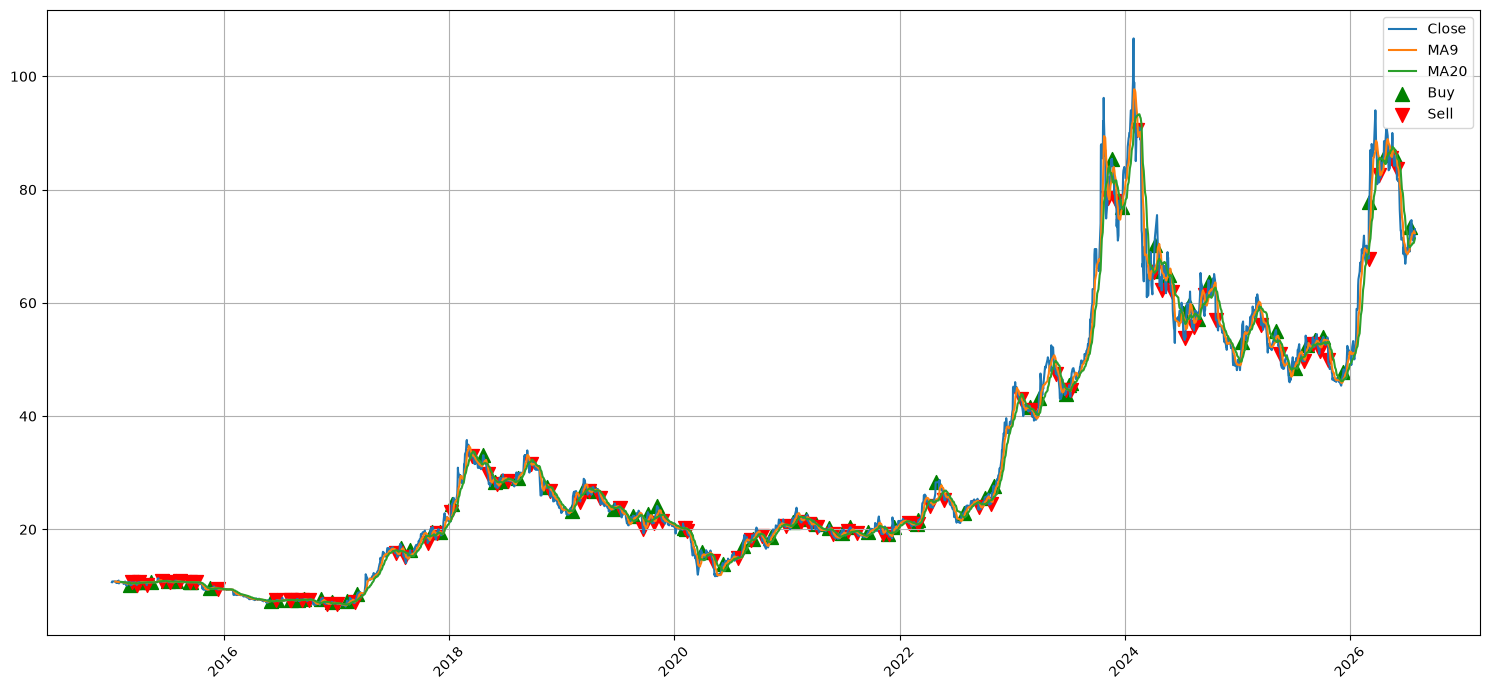

In [29]:
import matplotlib.pyplot as plt

df["date"] = pd.to_datetime(df["date"])

plt.figure(figsize=(15,7))

plt.plot(df["date"], df["close"], label="Close", linewidth=1.5)
plt.plot(df["date"], df["MA9"], label="MA9")
plt.plot(df["date"], df["MA20"], label="MA20")

plt.scatter(
    buy_dates,
    buy_prices,
    marker="^",
    color="green",
    s=100,
    label="Buy"
)

plt.scatter(
    sell_dates,
    sell_prices,
    marker="v",
    color="red",
    s=100,
    label="Sell"
)

plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()